In [1]:
import os, sys

util_path = '/home/core/davide/scripts/MUSE_scripts/MUSE_utils/'
sys.path.append(util_path)

import numpy as np
import PPXF_helper as ph # type: ignore
from PPXF_astrometry_correction import AstrometryCorrector # type: ignore
from PPXF_redshift_calculator import StellarKinematics, CubeUtils, ReadDataSpectrum # type: ignore
from PPXF_extinction_correction import GalacticExtinctionCorrector # type: ignore
from PPXF_fitting import stellar_kinematics, GasKinematicsFitter, GasKinematicsVoronoi # type: ignore
from PPXF_zapping import Zapping # type: ignore
from cutout_fits import download_panstarrs_fits, download_legacy_fits # type: ignore

from astroquery.ipac.ned import Ned  # type: ignore
from astropy.coordinates import SkyCoord
import astropy.units as u
from dustmaps.sfd import SFDQuery

import warnings
warnings.filterwarnings("ignore")

/home/core/davide/scripts/MUSE_scripts/MUSE_utils/PPXF_helper.py:22: UserWarning: ⚠️ VorBin is deprecated and superseded by PowerBin https://pypi.org/project/powerbin/ 
  from vorbin.voronoi_2d_binning import voronoi_2d_binning


In [3]:
# Set up the object to be analyzed and the corresponding logic for path handling

gal_NED_id = "NGC1453"

datasets_path = "/home/core/O1/davide/MUSE/datasets/"
cube = f"{datasets_path}/{gal_NED_id}/{gal_NED_id}.fits"
skycube = f"{datasets_path}/{gal_NED_id}_SKY/{gal_NED_id}_SKY.fits"

output_path = f"/home/core/O1/davide/MUSE/outputs/{gal_NED_id}/"
os.makedirs(output_path, exist_ok=True)

maps_path = f'{output_path}/maps/' 
os.makedirs(maps_path, exist_ok=True)

In [4]:
# Get position and redshift of the object from NED
print(f"\nPosition and redshift of {gal_NED_id} from NED catalogue:")

result_table = Ned.query_object(gal_NED_id)
ra_deg = result_table["RA"][0]
dec_deg = result_table["DEC"][0]   
z = result_table["Redshift"][0]   

c = SkyCoord(ra=ra_deg*u.degree, dec=dec_deg*u.degree)
ra_hms = c.ra.to_string(unit=u.hour, sep=('h', 'm', 's'), precision=4, pad=True)
dec_dms = c.dec.to_string(unit=u.degree, sep=('d', 'm', 's'), precision=3, alwayssign=True, pad=True)

print(f"\n- Position: {ra_hms}, {dec_dms} ({ra_deg}, {dec_deg})")
print("- Redshift: ", z)


Position and redshift of NGC1453 from NED catalogue:

- Position: 03h46m27.2280s, -03d58m07.752s (56.61345, -3.96882)
- Redshift:  0.012962


### 0. Zapping (sky-subtraction)

Filename: /home/core/O1/davide/MUSE/datasets//NGC1453/NGC1453.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1295   ()      
  1  DATA          1 ImageHDU        43   (363, 363, 3682)   float32   
  2  STAT          1 ImageHDU        43   (363, 363, 3682)   float32   
[INFO] Processing /home/core/O1/davide/MUSE/datasets//NGC1453_SKY/NGC1453_SKY.fits to compute the SVD
[INFO] Cleaning NaN values in the cube
[INFO] Rejected 6059 spaxels with more than 25.0% NaN pixels
[INFO] Fixing 542398 remaining NaN pixels
[INFO] _nanclean - Time: 4.80 sec.
[INFO] Extract to 2D, 90506 valid spaxels (93%)
[INFO] _extract - Time: 1.79 sec.
[INFO] Median zlevel subtraction
[INFO] _zlevel - Time: 3.58 sec.
[INFO] Applying Continuum Filter, cftype=median
[INFO] Using cfwidth=300
[INFO] _continuumfilter - Time: 57.77 sec.
[INFO] _prepare - Time: 70.17 sec.
[INFO] Calculating SVD on 1 segments ([[   0 3682]])
[INFO] _msvd - Time: 568.71 sec.
[INFO] Runni

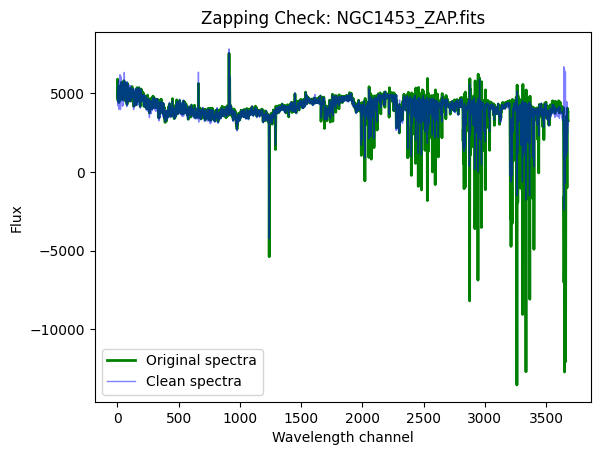

Zapping done. Check plot saved as: /home/core/O1/davide/MUSE/outputs/NGC1453/NGC1453_ZAP_check.png


In [5]:
# https://zap.readthedocs.io/en/latest/
# Notes: When the sky cube is not available the strategy is to mask the galaxy and use the residuals as sky map

cube_zapped = Zapping.do_zapping(cube, skycube, outdir=output_path)

### 1. WCS correction

Dec = -3.96882: Using Pan-STARRS
Successfully saved to /home/core/O1/davide/MUSE/outputs/NGC1453//NGC1453_ps1_rband.fits


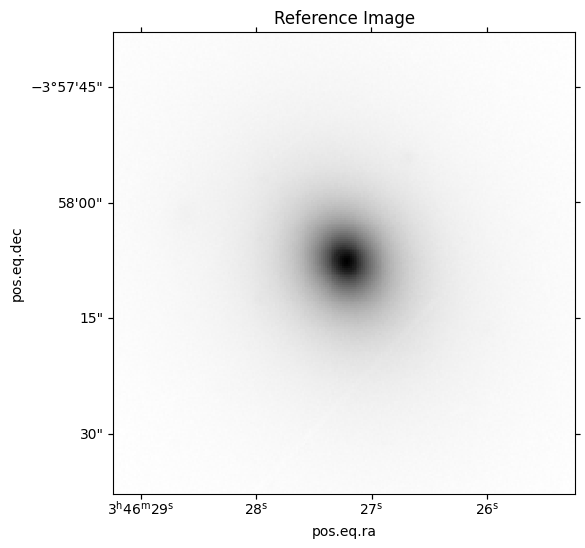

In [ ]:
if dec_deg <= -30:
    print(f"Dec = {dec_deg}: Using Legacy Survey")
    filepath = f"{output_path}/{gal_NED_id}_legacy_rband.fits"
    reference_fits = download_legacy_fits(ra_deg, dec_deg, size=230, filter="r", layer="ls-dr10", pixscale=0.262, filename=filepath)
else:
    print(f"Dec = {dec_deg}: Using Pan-STARRS")
    filepath = f"{output_path}/{gal_NED_id}_ps1_rband.fits"
    reference_fits = download_panstarrs_fits(ra_deg, dec_deg, size=240, filter="r", filename=filepath)

corrector = AstrometryCorrector(cube_filename=cube_zapped, reference_image_file=reference_fits)
corrector.show_reference()
corrector.show_white_image()
cube_zapped_aligned = corrector.apply_correction()

### Optional: cutting the cube and/or rebinning it by 2x2 pixels

In [6]:
size = 50 #pixels
cut_input = cube_zapped_aligned
cut_output = cut_input.replace(".fits", "_small.fits")

ph.cut_cube(cut_input, ra_hms, dec_dms, size, cut_output)
cube_zapped_aligned_cut = cut_output

bin_input = cube_zapped_aligned_cut
bin_output = bin_input.replace(".fits", "_2x2bin.fits")

ph.bin_muse_cube_by2(bin_input, outfile=bin_output)
cube_zapped_aligned_cut_binned = bin_output


NameError: name 'cube_zapped_aligned' is not defined

## 2. Correcting MW extinction

In [ ]:
# https://irsa.ipac.caltech.edu/applications/DUST/
# E(B-V) computed using Schlafly & Finkbeiner correction to Schlegel et al. 1998 values

sfd = SFDQuery()
ebv = sfd(c)*0.86

print('Mean E(B-V) reddening from S&F+11: {:.5f} mag'.format(ebv))

corr = GalacticExtinctionCorrector(ebv)
corrected_cube = corr.correct_cube(cube_zapped_aligned_cut_binned) # Use the correct cube depending if you performed the cut and the rebinning or not
print("Corrected cube written:", corrected_cube)

### 3. Calculate redshift

In [ ]:
# Typically absorption lines are used for the redshift instead of emission lines since the kinematics is not known.
# After the first fit with emission lines masked a sigma clipping is performed to remove outliers and a second fit is performed

'''
1. Extract the central spectrum:
2. Identify the brightest pixel in the Johnson-V image and extract the integrated 1-arcsecond radius spectrum around this peak.
3. Stellar kinematic fitting: Read the extracted 1D spectrum and fit it using the EMILES stellar population templates with pPXF.
Provide an initial guess for the kinematics via: start = [V, sigma]
Output:
Return the best-fitting redshift and its formal uncertainty, following the prescriptions of Cappellari (2023).
'''

redshift = z
radius = 1
peak_spectrum = CubeUtils.subtract_peak_spectrum(redshift, corrected_cube, radius)

s = ReadDataSpectrum(peak_spectrum, lam_range=[4500,7000], redshift=redshift)
sk = StellarKinematics(s)
z_fit, z_err = sk.setup_stellar_kinematics(start=[100, 200], redshift=redshift, width = 100) 



### 4. Fitting of the emission lines and stellar continuum using PPXF

In [ ]:

lam_range_temp = [4600, 7000]
redshift = round(z_fit, 6)

s = ph.read_data_cube(corrected_cube, lam_range_temp, redshift)
s.outfolder = maps_path
s.start = [0, 200.]    # (km/s), starting guess for [V,sigma]

valid = np.isfinite(s.noise)
median_noise = np.nanmedian(s.noise[valid])
s.noise[~valid] = median_noise

valid = np.isfinite(s.signal)
median_s = np.nanmedian(s.signal[valid])
s.signal[~valid] = median_s

s.redshift = redshift
print(s.x.size, s.y.size,s.signal.size,s.noise.size)

### 1. Voronoi binning and stellar kinematics
sk = stellar_kinematics(
    s=s,
    target_sn=100,
    noise=s.noise,
    signal=s.signal,
    width_lines=50,  # width to use to mask the emission lines
    plot = False 
)

stars = sk.stellar_kinematics()

### Create a narrow NII and Halpha image, and then fit the emission lines

This is useful to increase the S/N of the low-brightness gas

Creates a narrow band image using the continuum subtracted cube

Creates a voronoi tesselation based on the NII map to increase the S/N

Creates the cube based on that voronoi to increase the S/N

Later fits the emission lines 

In [ ]:
lam_range_temp = [4600, 7000]
redshift = round(z_fit, 6)

s = ph.read_data_cube(corrected_cube, lam_range_temp, redshift)
s.outfolder = maps_path

ph.make_narrowband_images(
    z=redshift,
    dv=300.0,
    output=s.outfolder
)

gas = GasKinematicsVoronoi(
    cube=s,
    stars=stars,
    pixsize=s.pixsize,
    fwhm_gal=s.fwhm_gal,
    target_sn=50
)

gas.build_gas_voronoi_bins()
gas.extract_binned_spectra()
gas.fit_gas()
gas.save_all_emission_lines_one_component(s.header)

### Fitting each spaxel individually - this is run in parallel

In [ ]:
fit_gas = GasKinematicsFitter(
    s=s,
    sps=stars.sps,
    lam_gal=stars.lam_gal,
    velbin=stars.velbin,
    sigbin=stars.sigbin,
    h3=stars.h3,
    h4=stars.h4,
    bin_num=stars.bin_num,
    optimal_templates=stars.optimal_templates
    )

fit_gas.fit_cube_one_component(n_jobs=10)
fit_gas.save_all_emission_lines_one_component(header=s.header)

In [ ]:
# Run all spaxels two gaussians
fit_gas.fit_cube()

# Build flux maps, component maps, weighted velocities
fit_gas.process_all_lines(s.header)
